## Understanding Logistic Regression

**A Comprehensive Guide with EDA, Sigmoid, Softmax, and Model Building**

- **Prerequisites:** Basic Python, familiarity with NumPy and Pandas
- **Dataset:** Sklearn Breast Cancer Dataset (built-in)

### Table of Contents

1. What is Classification in Machine Learning?
2. Introduction to Logistic Regression
3. The Math Behind Logistic Regression
4. The Sigmoid Function
5. The Softmax Function
6. Dataset and Exploratory Data Analysis (EDA)
7. Building the Logistic Regression Model
8. Model Evaluation
9. Sigmoid vs Softmax: A Comparison
10. Key Takeaways

### 1. What is Classification in Machine Learning?

**Classification** is a type of supervised learning where the model learns to assign input data to one of several predefined **discrete categories** (classes).

Unlike regression, which predicts continuous values (e.g., price, temperature), classification predicts **categorical labels** (e.g., spam/not spam, disease/no disease).

#### Types of Classification

| Type | Description | Example |
|------|-------------|---------|
| **Binary Classification** | Two possible classes | Email: Spam or Not Spam |
| **Multi-Class Classification** | More than two classes | Digit recognition: 0-9 |
| **Multi-Label Classification** | Multiple labels per sample | Article tagging: Sports, Politics |

#### Classification vs Regression

| Feature | Classification | Regression |
|---------|---------------|------------|
| **Output** | Discrete class labels | Continuous numeric values |
| **Example** | Is this tumor malignant? | What is the house price? |
| **Algorithms** | Logistic Regression, SVM, Decision Trees | Linear Regression, Ridge, Lasso |
| **Evaluation Metrics** | Accuracy, Precision, Recall, F1 | MAE, MSE, R-squared |

#### Common Classification Algorithms

- Logistic Regression
- Decision Trees and Random Forests
- Support Vector Machines (SVM)
- K-Nearest Neighbors (KNN)
- Naive Bayes
- Neural Networks

### 2. Introduction to Logistic Regression

Despite its name, **Logistic Regression** is a **classification** algorithm, not a regression algorithm. It is used to predict the probability that a given input belongs to a particular class.

#### Why Not Use Linear Regression for Classification?

Linear regression outputs continuous values that can range from negative infinity to positive infinity. For classification, we need outputs that represent **probabilities** (values between 0 and 1).

Problems with linear regression for classification:

- Output values can be less than 0 or greater than 1
- Sensitive to outliers, which can shift the decision boundary significantly
- Does not model the probability distribution of classes properly

#### How Logistic Regression Works

1. Compute a linear combination of input features: $z = w_1x_1 + w_2x_2 + ... + w_nx_n + b$
2. Pass the result through the **Sigmoid function** to get a probability between 0 and 1
3. Apply a **threshold** (typically 0.5) to assign the final class label

#### Decision Boundary

The decision boundary is the threshold where the model switches its prediction from one class to another. For a default threshold of 0.5:

- If $P(y=1|x) \geq 0.5$, predict class 1
- If $P(y=1|x) < 0.5$, predict class 0

### 3. The Math Behind Logistic Regression

#### Step 1: Linear Equation

$$z = w^T x + b = w_1x_1 + w_2x_2 + ... + w_nx_n + b$$

Where:
- $w$ = weight vector (learned parameters)
- $x$ = input feature vector
- $b$ = bias term

#### Step 2: Sigmoid Activation

The linear output $z$ is passed through the **Sigmoid function** to convert it into a probability:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Properties of the Sigmoid function:
- Output is always between 0 and 1
- When $z = 0$, output = 0.5
- When $z \to +\infty$, output approaches 1
- When $z \to -\infty$, output approaches 0

#### Step 3: Log-Odds (Logit Function)

The inverse of the sigmoid is called the **logit function**:

$$\text{logit}(p) = \ln\left(\frac{p}{1-p}\right) = w^Tx + b$$

This tells us that logistic regression models the **log-odds** of the positive class as a linear function of the input features.

#### Step 4: Cost Function (Binary Cross-Entropy / Log Loss)

The cost function used in logistic regression is the **Log Loss** (Binary Cross-Entropy):

$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

Where:
- $m$ = number of training samples
- $y^{(i)}$ = actual label (0 or 1)
- $\hat{y}^{(i)}$ = predicted probability

#### Step 5: Optimization (Gradient Descent)

The model learns the optimal weights $w$ and bias $b$ by minimizing the cost function using **Gradient Descent**:

$$w := w - \alpha \frac{\partial J}{\partial w}$$

$$b := b - \alpha \frac{\partial J}{\partial b}$$

Where $\alpha$ is the **learning rate**.

### 4. The Sigmoid Function

The Sigmoid function maps any real-valued number to a value between 0 and 1, making it ideal for binary classification.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Its derivative is:

$$\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$$

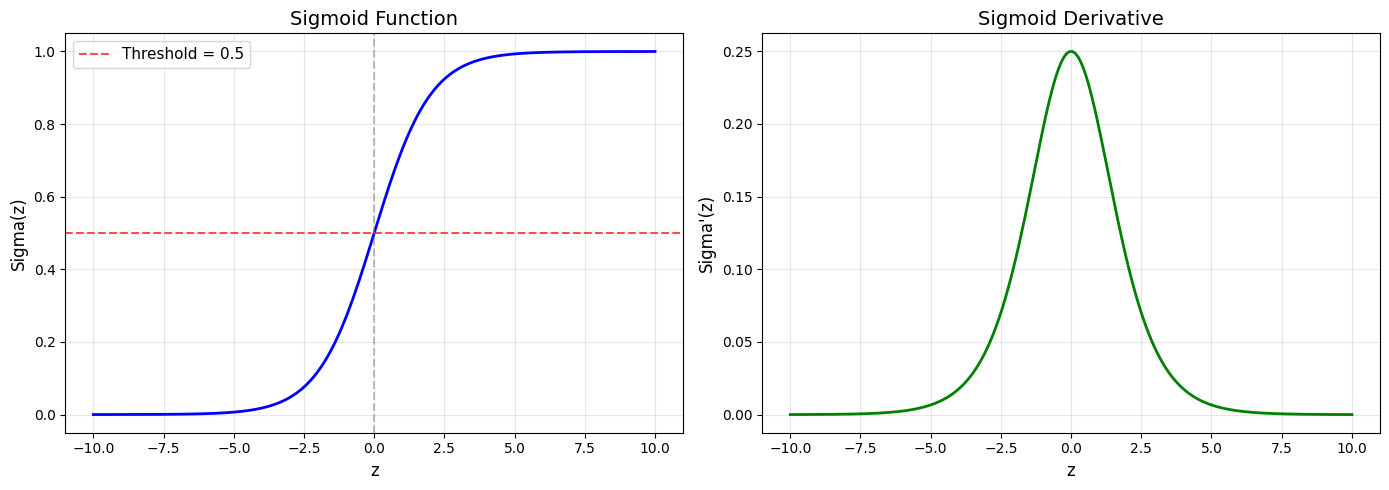

Key Sigmoid Values:
  sigmoid(-10) = 0.000045
  sigmoid(-5)  = 0.006693
  sigmoid(0)   = 0.500000
  sigmoid(5)   = 0.993307
  sigmoid(10)  = 0.999955


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sigmoid Function Implementation ---

def sigmoid(z):
    """Compute the sigmoid of z."""
    return 1 / (1 + np.exp(-z))

# Generate values for z
z = np.linspace(-10, 10, 200)

# Compute sigmoid values
sigma_z = sigmoid(z)

# Plot the Sigmoid function
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sigmoid function
axes[0].plot(z, sigma_z, color='blue', linewidth=2)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Threshold = 0.5')
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Sigmoid Function', fontsize=14)
axes[0].set_xlabel('z', fontsize=12)
axes[0].set_ylabel('Sigma(z)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.05, 1.05)

# Plot 2: Sigmoid derivative
sigma_derivative = sigma_z * (1 - sigma_z)
axes[1].plot(z, sigma_derivative, color='green', linewidth=2)
axes[1].set_title('Sigmoid Derivative', fontsize=14)
axes[1].set_xlabel('z', fontsize=12)
axes[1].set_ylabel("Sigma'(z)", fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Demonstrate key sigmoid values
print("Key Sigmoid Values:")
print(f"  sigmoid(-10) = {sigmoid(-10):.6f}")
print(f"  sigmoid(-5)  = {sigmoid(-5):.6f}")
print(f"  sigmoid(0)   = {sigmoid(0):.6f}")
print(f"  sigmoid(5)   = {sigmoid(5):.6f}")
print(f"  sigmoid(10)  = {sigmoid(10):.6f}")

p[0.3,0.6,0.2]
0.62-A , 0.6 - B , 0.2 - C, 

### 5. The Softmax Function

While the Sigmoid function is used for **binary classification**, the **Softmax function** is the generalization used for **multi-class classification**.

It converts a vector of raw scores (logits) into a probability distribution over multiple classes.

#### Softmax Formula

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

Where:
- $z_i$ = raw score (logit) for class $i$
- $K$ = total number of classes
- The output probabilities sum to 1

#### Properties

- All output values are between 0 and 1
- The sum of all output values equals 1
- Higher logit values get higher probabilities
- It amplifies the differences between logit values

Softmax Demonstration:
  Raw logits:     [2.  1.  0.1 4.  1.5]
  Probabilities:  [0.1051 0.0387 0.0157 0.7767 0.0638]
  Sum of probs:   1.0000
  Predicted class: Class D


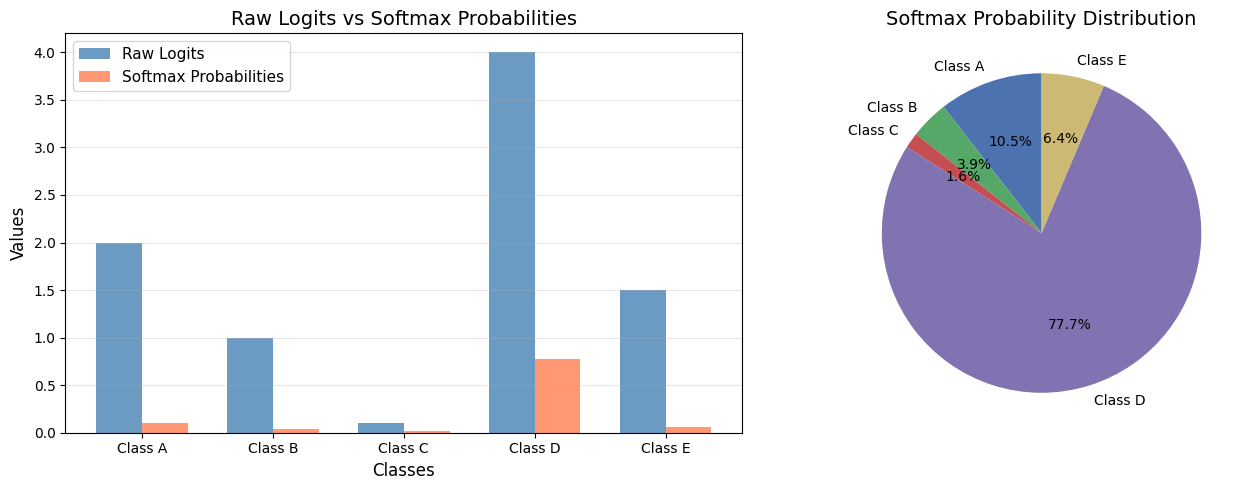

In [2]:
# --- Softmax Function Implementation ---

def softmax(z):
    """Compute the softmax of vector z."""
    # Subtract max for numerical stability
    exp_z = np.exp(z - np.max(z))
    return exp_z / exp_z.sum()

# Example: Raw logits for 5 classes
logits = np.array([2.0, 1.0, 0.1, 4.0, 1.5])
class_names = ['Class A', 'Class B', 'Class C', 'Class D', 'Class E']

# Compute softmax probabilities
probabilities = softmax(logits)

print("Softmax Demonstration:")
print(f"  Raw logits:     {logits}")
print(f"  Probabilities:  {np.round(probabilities, 4)}")
print(f"  Sum of probs:   {probabilities.sum():.4f}")
print(f"  Predicted class: {class_names[np.argmax(probabilities)]}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Raw logits vs Softmax probabilities
x = np.arange(len(class_names))
width = 0.35
axes[0].bar(x - width/2, logits, width, label='Raw Logits', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, probabilities, width, label='Softmax Probabilities', color='coral', alpha=0.8)
axes[0].set_xlabel('Classes', fontsize=12)
axes[0].set_ylabel('Values', fontsize=12)
axes[0].set_title('Raw Logits vs Softmax Probabilities', fontsize=14)
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Softmax probability distribution (pie chart)
axes[1].pie(probabilities, labels=class_names, autopct='%1.1f%%', startangle=90,
            colors=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'])
axes[1].set_title('Softmax Probability Distribution', fontsize=14)

plt.tight_layout()
plt.show()

### 6. Dataset and Exploratory Data Analysis (EDA)

We will use the **Breast Cancer Wisconsin Dataset** from sklearn. This is a binary classification dataset with:

- **569 samples**
- **30 numerical features** (computed from digitized images of breast mass)
- **2 classes:** Malignant (0) and Benign (1)

EDA helps us understand the structure, distribution, and relationships in the data before building a model.

#### 6.1 Load and Inspect the Dataset

In [4]:
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Load the dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['target'] 

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int32

In [5]:


# Map target labels for readability
target_map = {0: 'Malignant', 1: 'Benign'}
df['target_label'] = df['target'].map(target_map)

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (569, 32)

First 5 Rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [6]:
# Data types and non-null counts
print("Data Types and Non-Null Counts:")
print(df.dtypes.value_counts())
print(f"\nTotal columns: {df.shape[1]}")
print(f"Total rows: {df.shape[0]}")

Data Types and Non-Null Counts:
float64    30
int32       1
object      1
Name: count, dtype: int64

Total columns: 32
Total rows: 569


#### 6.2 Statistical Summary

In [7]:
# Descriptive statistics
print("Statistical Summary (first 10 features):")
print(df.iloc[:, :10].describe().round(2))

Statistical Summary (first 10 features):
       mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
count       569.00        569.00          569.00     569.00           569.00   
mean         14.13         19.29           91.97     654.89             0.10   
std           3.52          4.30           24.30     351.91             0.01   
min           6.98          9.71           43.79     143.50             0.05   
25%          11.70         16.17           75.17     420.30             0.09   
50%          13.37         18.84           86.24     551.10             0.10   
75%          15.78         21.80          104.10     782.70             0.11   
max          28.11         39.28          188.50    2501.00             0.16   

       mean compactness  mean concavity  mean concave points  mean symmetry  \
count            569.00          569.00               569.00         569.00   
mean               0.10            0.09                 0.05           0.18   
s

#### 6.3 Check for Missing Values

In [8]:
# Check for missing values
missing = df.isnull().sum()
print("Missing Values Per Column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")
print(f"\nTotal missing values: {missing.sum()}")

Missing Values Per Column:
No missing values found.

Total missing values: 0


#### 6.4 Target Class Distribution

In [9]:
# Class distribution
print("Target Class Distribution:")
print(df['target_label'].value_counts())
print(f"\nClass Ratio (Benign / Malignant): {df['target'].value_counts()[1] / df['target'].value_counts()[0]:.2f}")

Target Class Distribution:
target_label
Benign       357
Malignant    212
Name: count, dtype: int64

Class Ratio (Benign / Malignant): 1.68


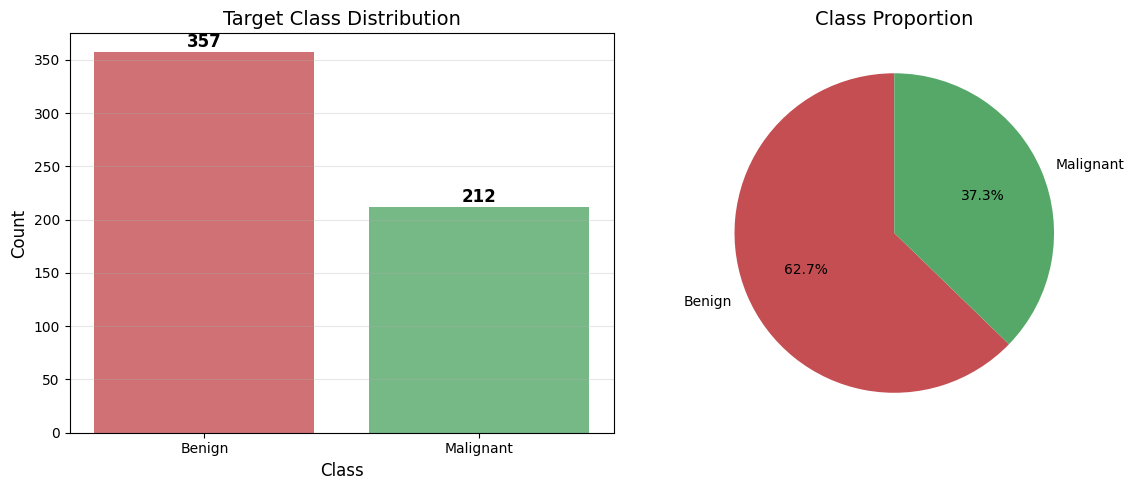

In [10]:


# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
class_counts = df['target_label'].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=['#C44E52', '#55A868'], alpha=0.8)
axes[0].set_title('Target Class Distribution', fontsize=14)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=['#C44E52', '#55A868'], startangle=90)
axes[1].set_title('Class Proportion', fontsize=14)

plt.tight_layout()
plt.show()

#### 6.5 Feature Distributions (Top Features)

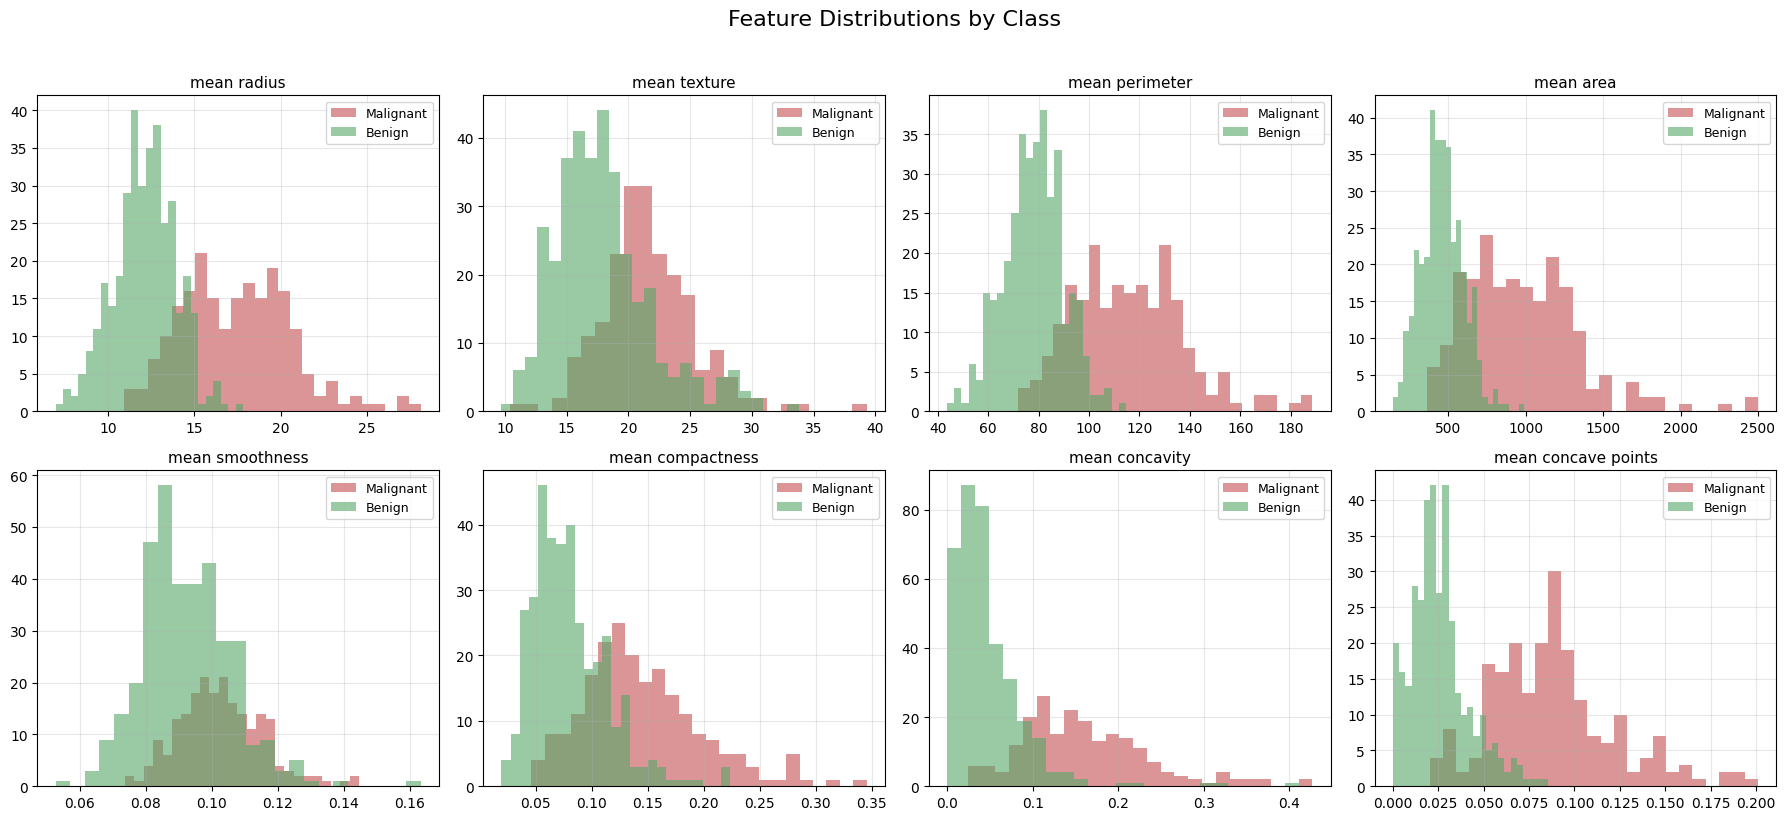

In [11]:
# Histograms for top 8 features
top_features = data.feature_names[:8]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    for label, color in zip([0, 1], ['#C44E52', '#55A868']):
        subset = df[df['target'] == label][feature]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=target_map[label])
    axes[i].set_title(feature, fontsize=11)
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Feature Distributions by Class', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#### 6.6 Correlation Heatmap

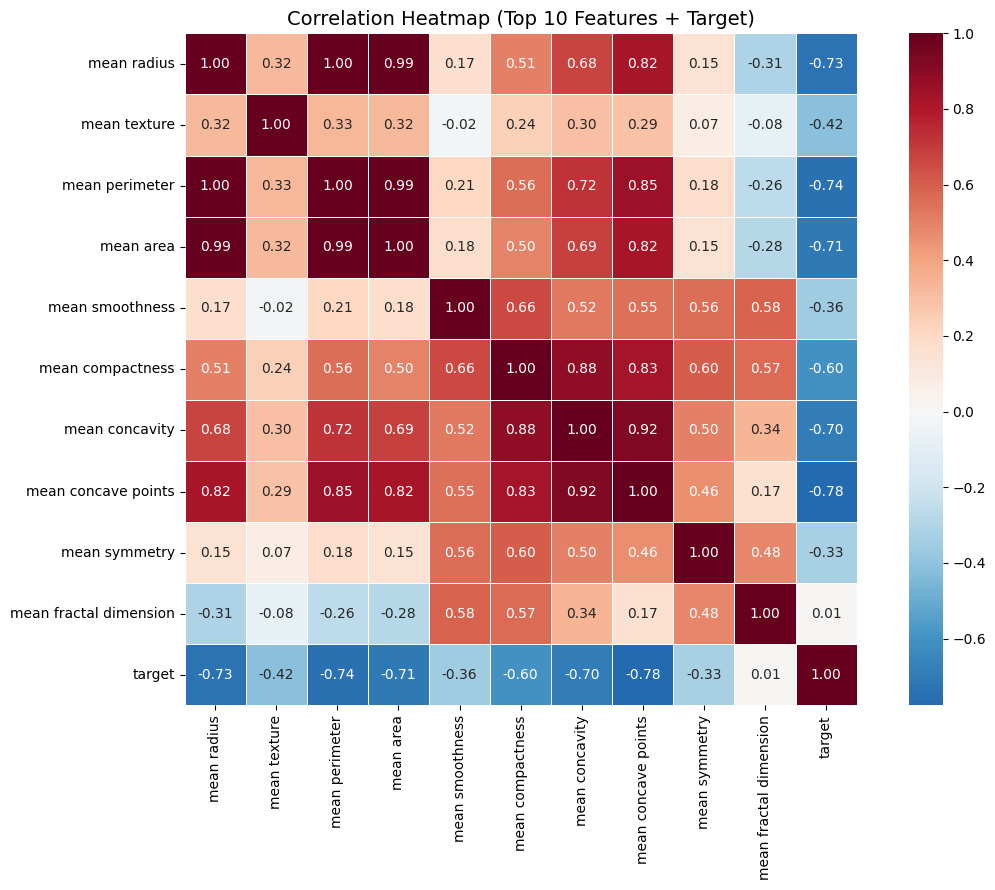

In [12]:
# Correlation heatmap for top 10 features + target
selected_cols = list(data.feature_names[:10]) + ['target']
corr_matrix = df[selected_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Top 10 Features + Target)', fontsize=14)
plt.tight_layout()
plt.show()

a- 8 hrs - 90
b - 5hrs - 80
c - 7 hrs - 87



hrs and Scores are realtes

#### 6.7 Pairplot (Selected Features)

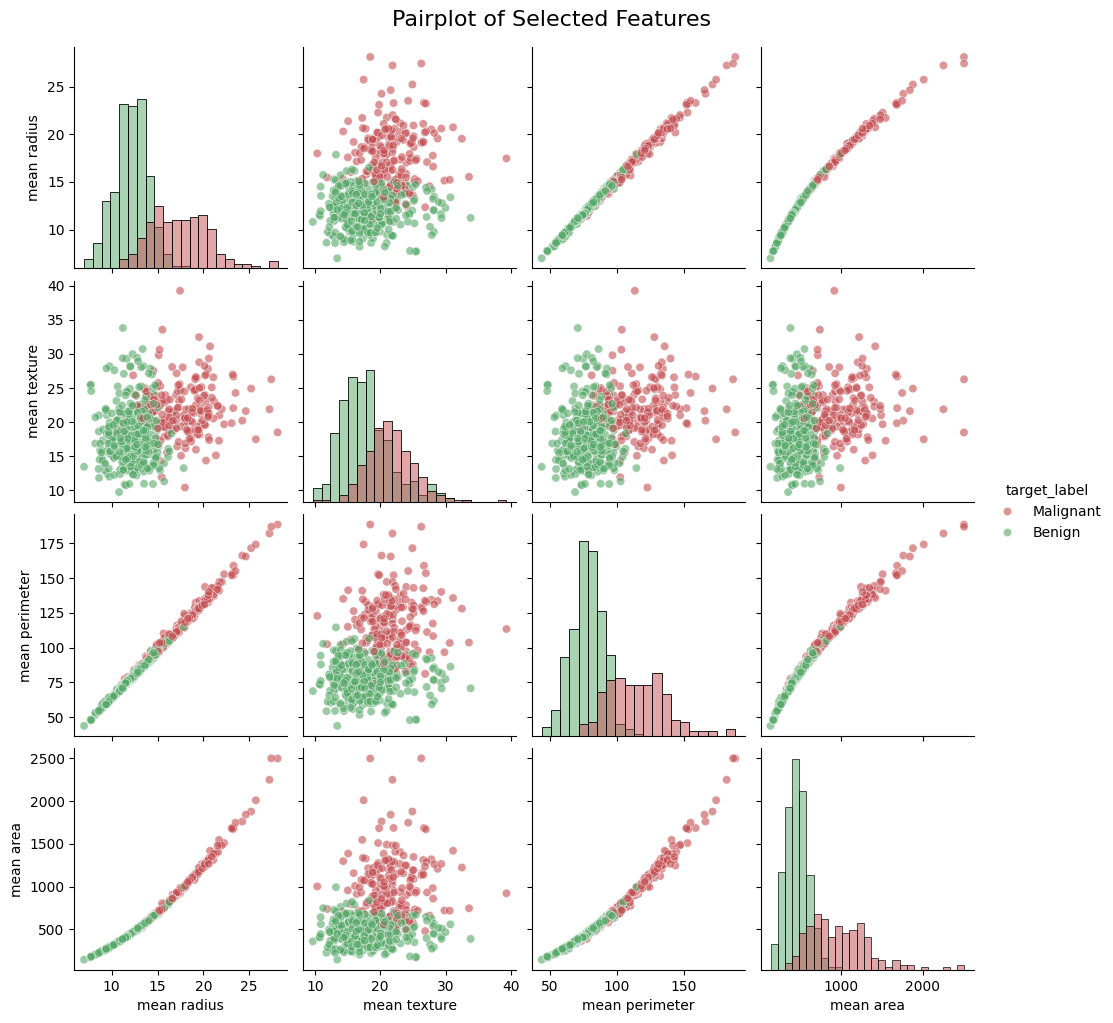

In [13]:
# Pairplot for selected features
selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']

sns.pairplot(df, vars=selected_features, hue='target_label',
             palette={'Malignant': '#C44E52', 'Benign': '#55A868'},
             diag_kind='hist', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Selected Features', fontsize=16, y=1.02)
plt.show()

### 7. Building the Logistic Regression Model

Steps involved:

1. Split the data into training and testing sets
2. Standardize the features using StandardScaler
3. Train a Logistic Regression model
4. Make predictions on the test set

In [14]:
1,10,100,1000
1/1000,10/1000, 100/1000,1000/1000

(0.001, 0.01, 0.1, 1.0)

- train used for Model training (Xtrain and Ytrain)

- Xtest and Ytest
Yprect = A.Xtest
Ytest = Actual

Yprec and Ytest 
 1         1    TP
 0         0     TN 
 Accu = TP+TN/(TP+TN_FP+FN) 
 

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Prepare features and target
X = df[data.feature_names]
y = df['target']

# Step 1: Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")

Training set size: 455 samples
Testing set size:  114 samples


In [16]:
 ##Step 2: Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures scaled using StandardScaler.")
print(f"Training mean (first feature): {X_train_scaled[:, 0].mean():.4f}")
print(f"Training std (first feature):  {X_train_scaled[:, 0].std():.4f}")


Features scaled using StandardScaler.
Training mean (first feature): -0.0000
Training std (first feature):  1.0000


In [17]:

# Step 3: Train Logistic Regression model
model = LogisticRegression(max_iter=100, random_state=42)
model.fit(X_train_scaled, y_train)

print(f"\nModel trained successfully.")
print(f"Number of iterations: {model.n_iter_[0]}")

# Step 4: Make predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"\nPredictions generated for {len(y_pred)} test samples.")
print(f"Sample predictions (first 10): {y_pred[:10]}")
print(f"Sample probabilities (first 10): {np.round(y_pred_proba[:10], 3)}")


Model trained successfully.
Number of iterations: 33

Predictions generated for 114 test samples.
Sample predictions (first 10): [0 1 0 1 0 1 1 0 0 0]
Sample probabilities (first 10): [0.    1.    0.006 0.536 0.    0.992 1.    0.    0.    0.   ]


### 8. Model Evaluation

We evaluate the model using multiple metrics to get a comprehensive understanding of its performance.

#### 8.1 Accuracy and Classification Report

In [18]:
from sklearn.metrics import accuracy_score, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

Model Accuracy: 0.9825 (98.25%)

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



#### 8.2 Confusion Matrix

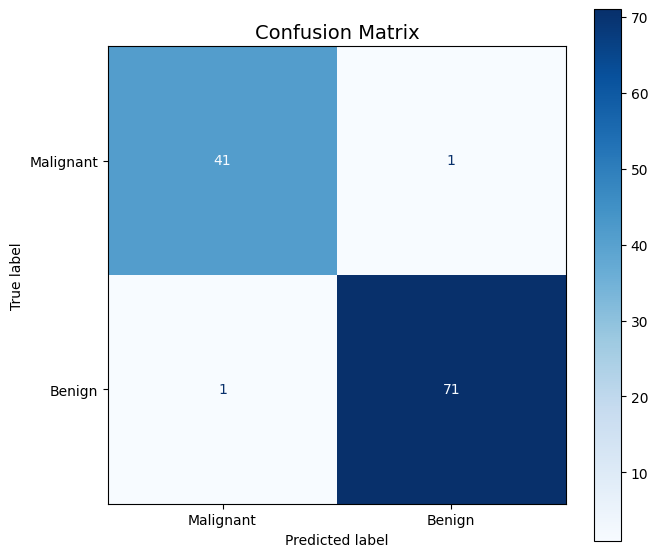

True Negatives (TN):  41  - Correctly predicted Malignant
False Positives (FP): 1  - Malignant predicted as Benign
False Negatives (FN): 1  - Benign predicted as Malignant
True Positives (TP):  71  - Correctly predicted Benign


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant', 'Benign'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Print interpretation
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN):  {tn}  - Correctly predicted Malignant")
print(f"False Positives (FP): {fp}  - Malignant predicted as Benign")
print(f"False Negatives (FN): {fn}  - Benign predicted as Malignant")
print(f"True Positives (TP):  {tp}  - Correctly predicted Benign")

#### 8.3 ROC Curve and AUC Score

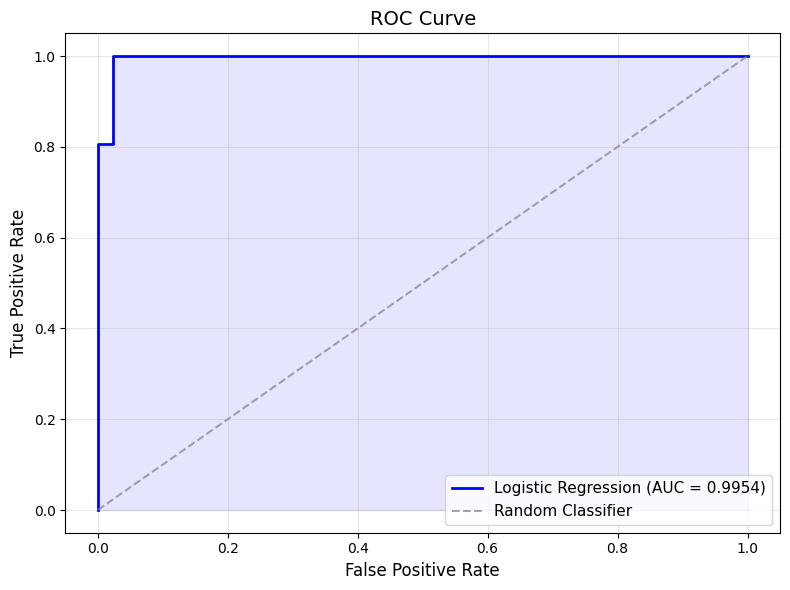

AUC Score: 0.9954

Interpretation:
  AUC = 1.0: Perfect classifier
  AUC = 0.5: Random classifier (no discrimination)
  Our model AUC = 0.9954: Excellent performance


In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.7, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='blue')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")
print("\nInterpretation:")
print("  AUC = 1.0: Perfect classifier")
print("  AUC = 0.5: Random classifier (no discrimination)")
print(f"  Our model AUC = {auc_score:.4f}: {'Excellent' if auc_score >= 0.9 else 'Good' if auc_score >= 0.8 else 'Fair'} performance")

### 9. Sigmoid vs Softmax: A Comparison

| Feature | Sigmoid | Softmax |
|---------|---------|---------|
| **Use Case** | Binary classification | Multi-class classification |
| **Output Range** | Single value between 0 and 1 | Vector of values, each between 0 and 1 |
| **Sum of Outputs** | Does not necessarily sum to 1 | Always sums to 1 |
| **Formula** | $\sigma(z) = \frac{1}{1+e^{-z}}$ | $\text{softmax}(z_i) = \frac{e^{z_i}}{\sum e^{z_j}}$ |
| **Number of Outputs** | 1 (probability of positive class) | K (one per class) |
| **Relationship** | Special case of Softmax when K=2 | Generalization of Sigmoid |
| **Loss Function** | Binary Cross-Entropy | Categorical Cross-Entropy |

**Key Insight:** When there are only 2 classes, Softmax reduces to the Sigmoid function. Sigmoid can be seen as a special case of Softmax.

### 10. Key Takeaways

---

1. **Classification** is a supervised learning task that predicts discrete class labels, unlike regression which predicts continuous values.
2. **Logistic Regression** is a linear model used for classification. It uses the Sigmoid function to map predictions to probabilities.
3. The **Sigmoid function** outputs values between 0 and 1, making it ideal for binary classification tasks.
4. The **Softmax function** generalizes the Sigmoid to multi-class problems, producing a probability distribution over all classes.
5. Logistic Regression uses **Log Loss (Binary Cross-Entropy)** as its cost function and optimizes it using Gradient Descent.
6. **EDA is essential** before model building. It helps identify data quality issues, class imbalance, feature correlations, and distribution patterns.
7. **Feature scaling** (StandardScaler) is important for logistic regression since it is sensitive to the magnitude of input features.
8. Model evaluation should go beyond accuracy. Use **Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC** for a complete picture.
9. The **ROC-AUC score** provides a threshold-independent measure of classification performance.
10. Logistic Regression is simple, interpretable, and often serves as a strong **baseline model** before trying more complex algorithms.